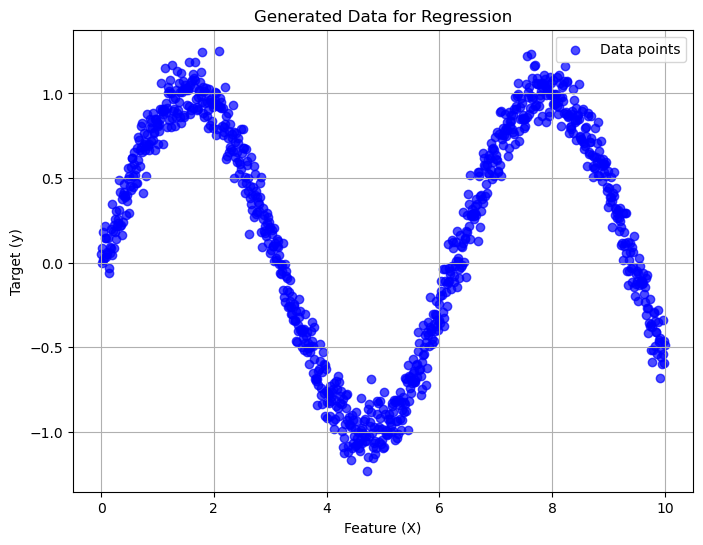

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# 生成虚拟数据集
X = np.linspace(0, 10, 1000).reshape(-1, 1)  # 1000个数据点
y = np.sin(X) + 0.1 * np.random.randn(1000, 1)  # 添加噪声的sin函数

# 绘制数据图
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Data points', alpha=0.7)
plt.title('Generated Data for Regression')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化随机森林回归器
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 训练模型
rf_model.fit(X_train, y_train)

# 预测
y_pred = rf_model.predict(X_test)

# 计算均方误差
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error on Test Set: {mse:.4f}')

Mean Squared Error on Test Set: 0.0139


c:\Users\Think\anaconda3\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


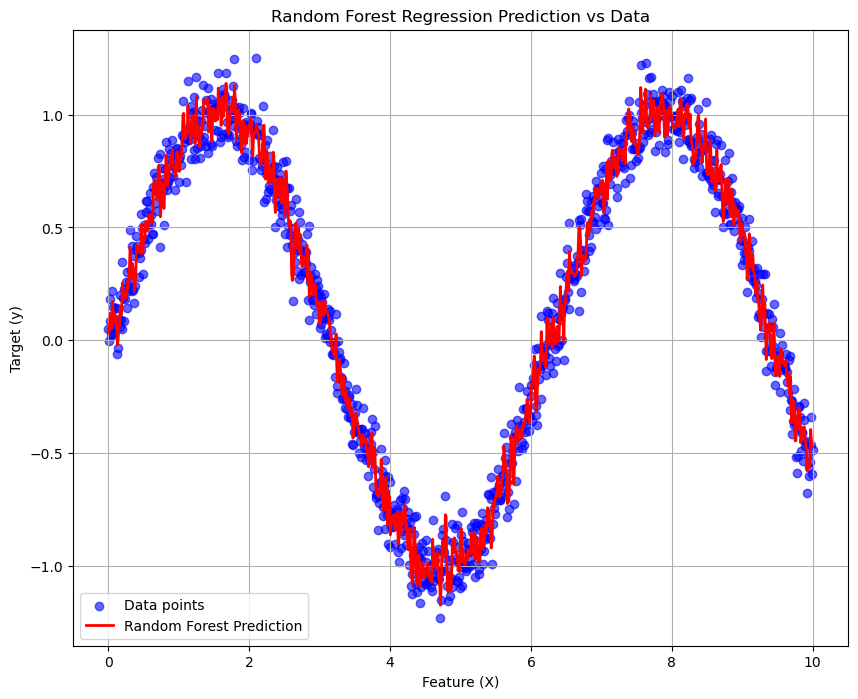

In [3]:
X_range = np.linspace(0, 10, 1000).reshape(-1, 1)
y_pred_range = rf_model.predict(X_range)

plt.figure(figsize=(10, 8))
plt.scatter(X, y, color='blue', label='Data points', alpha=0.6)
plt.plot(X_range, y_pred_range, color='red', label='Random Forest Prediction', linewidth=2)
plt.title('Random Forest Regression Prediction vs Data')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from bayes_opt import BayesianOptimization

# 定义目标函数（即优化函数）
def rf_cv(n_estimators, max_depth):
    # 将超参数转换为整数
    n_estimators = int(n_estimators)
    max_depth = int(max_depth)

    # 使用给定的超参数训练模型
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)
    
    # 预测并计算均方误差
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    # 返回负均方误差，因为贝叶斯优化最小化目标函数
    return -mse

# 设置贝叶斯优化的超参数搜索范围
pbounds = {'n_estimators': (10, 200), 'max_depth': (1, 20)}

# 初始化贝叶斯优化器
optimizer = BayesianOptimization(f=rf_cv, pbounds=pbounds, random_state=42)

# 开始优化
optimizer.maximize(init_points=5, n_iter=25)

# 输出最优参数组合
print("Best parameters found:", optimizer.max['params'])

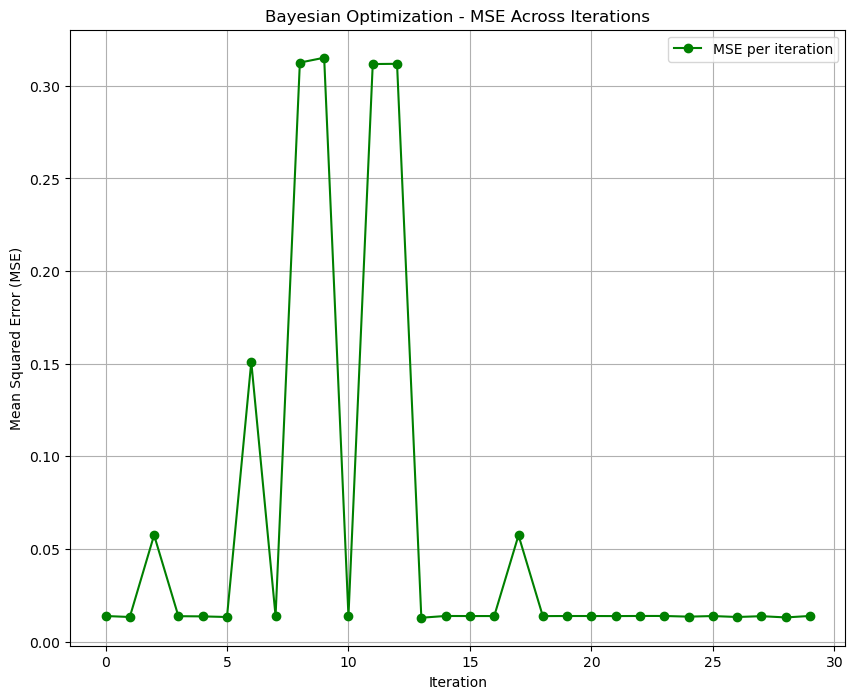

In [6]:
# 获取贝叶斯优化的结果并绘制均方误差曲线
iterations = np.arange(len(optimizer.res))
mse_values = [-res['target'] for res in optimizer.res]

plt.figure(figsize=(10, 8))
plt.plot(iterations, mse_values, marker='o', color='green', label='MSE per iteration')
plt.title('Bayesian Optimization - MSE Across Iterations')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

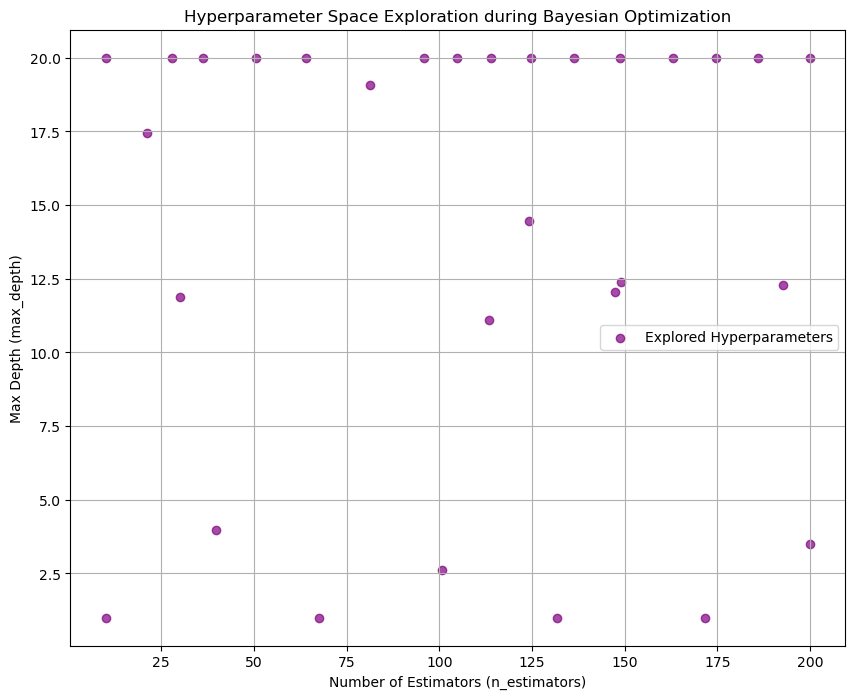

In [7]:
# 绘制超参数空间的探索情况
n_estimators_values = [res['params']['n_estimators'] for res in optimizer.res]
max_depth_values = [res['params']['max_depth'] for res in optimizer.res]

plt.figure(figsize=(10, 8))
plt.scatter(n_estimators_values, max_depth_values, color='purple', label='Explored Hyperparameters', alpha=0.7)
plt.title('Hyperparameter Space Exploration during Bayesian Optimization')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Max Depth (max_depth)')
plt.legend()
plt.grid(True)
plt.show()

c:\Users\Think\anaconda3\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


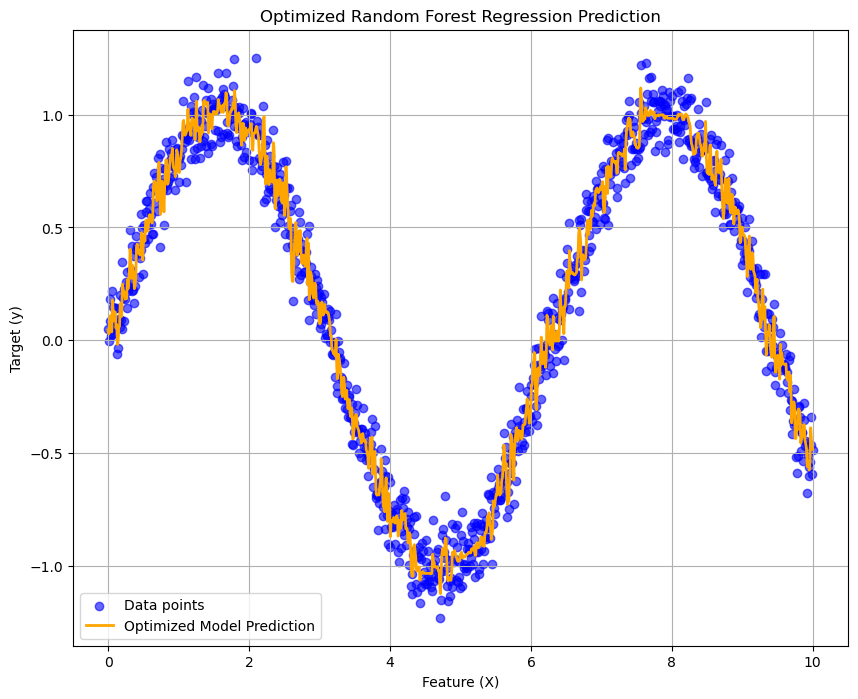

In [8]:
# 使用最优超参数训练最终模型并绘制预测结果
best_params = optimizer.max['params']
best_model = RandomForestRegressor(n_estimators=int(best_params['n_estimators']),
                                   max_depth=int(best_params['max_depth']), random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_range)

plt.figure(figsize=(10, 8))
plt.scatter(X, y, color='blue', label='Data points', alpha=0.6)
plt.plot(X_range, y_pred_best, color='orange', label='Optimized Model Prediction', linewidth=2)
plt.title('Optimized Random Forest Regression Prediction')
plt.xlabel('Feature (X)')
plt.ylabel('Target (y)')
plt.legend()
plt.grid(True)
plt.show()